In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
import seaborn as sns
from sklearn.metrics import (mean_squared_error, mean_absolute_error, 
                            r2_score, explained_variance_score)
from yellowbrick.regressor import (residuals_plot, prediction_error)
import shap
from sklearn.base import clone
from scipy import stats
import joblib

In [2]:
model = joblib.load("../../../../models/xgboost/xgboost_model_label_v6.joblib")

In [3]:
df = pd.read_csv('../../../../data/preprocessed/selected_features_dataset_V2.csv')

X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


In [16]:
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    explained_variance_score, mean_absolute_percentage_error
)
import numpy as np
import pandas as pd

def calculate_metrics(model, X_train, X_test, y_train, y_test):
    """Calculate regression metrics including MAPE and average prices (actual & predicted)"""
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    metrics = {
        'Train R²': r2_score(y_train, y_pred_train),
        'Test R²': r2_score(y_test, y_pred_test),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'Train MAE': mean_absolute_error(y_train, y_pred_train),
        'Test MAE': mean_absolute_error(y_test, y_pred_test),
        'Train MAPE (%)': mean_absolute_percentage_error(y_train, y_pred_train) * 100,
        'Test MAPE (%)': mean_absolute_percentage_error(y_test, y_pred_test) * 100,
        'Explained Variance': explained_variance_score(y_test, y_pred_test),
        'Train-Test R² Gap': abs(r2_score(y_train, y_pred_train) - r2_score(y_test, y_pred_test)),
        'Avg Actual Train Price': np.mean(y_train),
        'Avg Predicted Train Price': np.mean(y_pred_train),
        'Avg Actual Test Price': np.mean(y_test),
        'Avg Predicted Test Price': np.mean(y_pred_test)
    }
    
    return pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])

# Usage
metrics_df = calculate_metrics(model, X_train, X_test, y_train, y_test)
print(metrics_df)

                                 Value
Train R²                      0.877007
Test R²                       0.870612
Train RMSE                  624.366392
Test RMSE                   623.120111
Train MAE                   429.923871
Test MAE                    442.578064
Train MAPE (%)              121.189009
Test MAPE (%)               121.073527
Explained Variance            0.870880
Train-Test R² Gap             0.006395
Avg Actual Train Price     1573.736847
Avg Predicted Train Price  1578.864258
Avg Actual Test Price      1596.474432
Avg Predicted Test Price   1624.813965


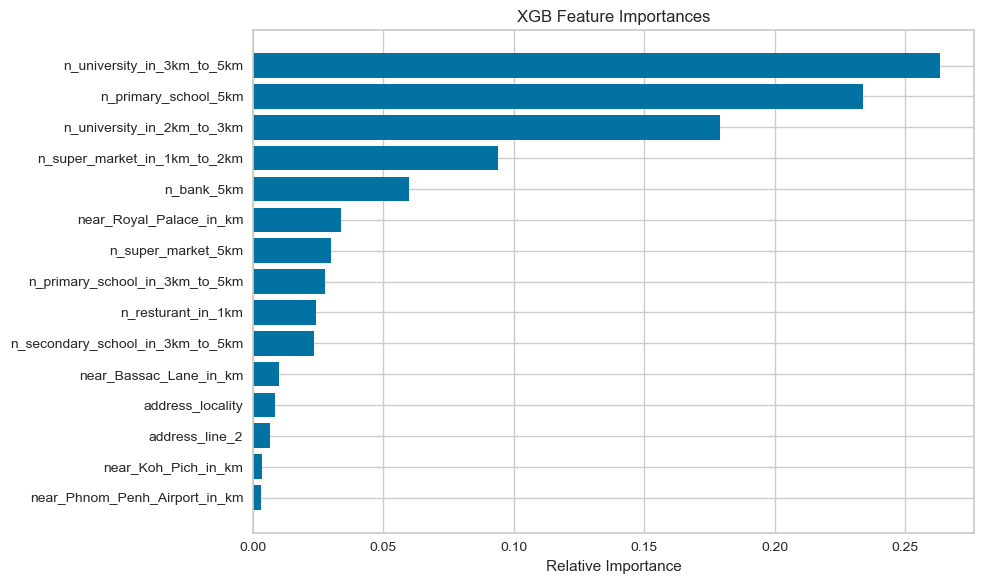

In [6]:
def plot_feature_importance(model, feature_names, top_n=20):
    """Plot horizontal bar chart of feature importance"""
    importances = model.feature_importances_
    indices = np.argsort(importances)[-top_n:]
    
    plt.figure(figsize=(10, 6))
    plt.title(f'XGB Feature Importances')
    plt.barh(range(len(indices)), importances[indices], color='b', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.tight_layout()
    plt.show()

plot_feature_importance(model, X_train.columns)

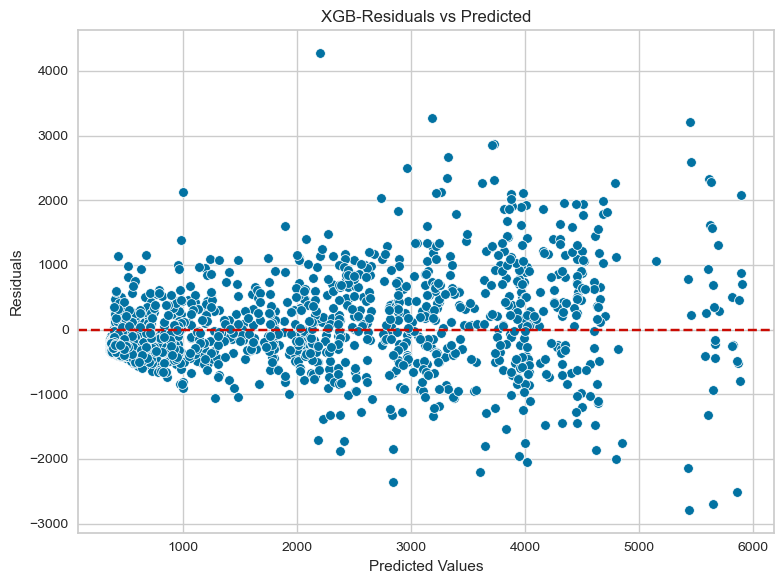

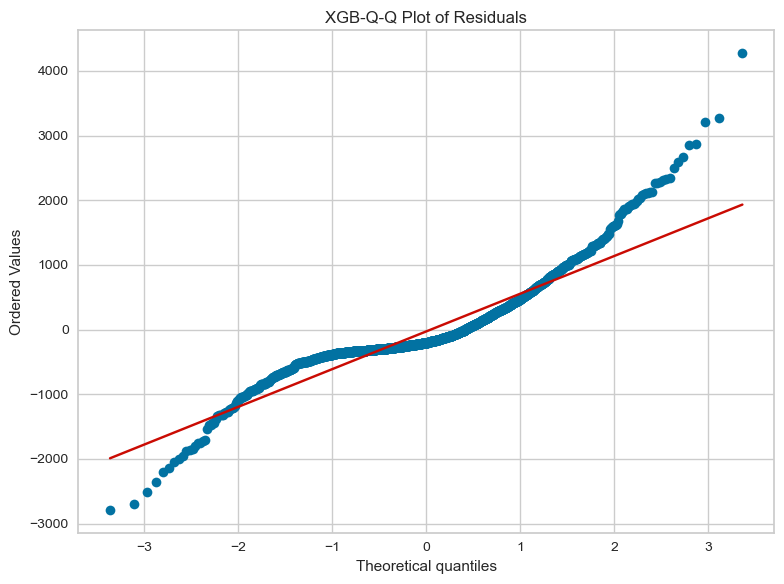

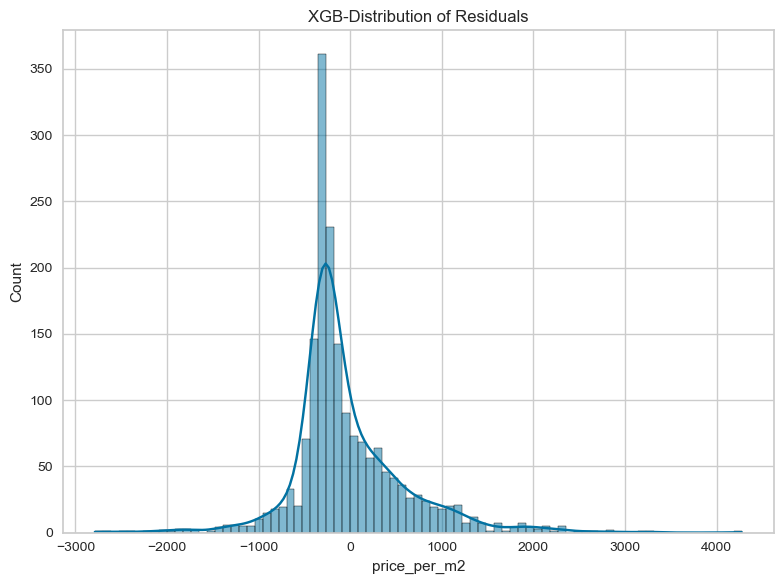

In [7]:
def plot_residuals_one_by_one(model, X_train, X_test, y_train, y_test):
    """Generate residual diagnostic plots, showing them one by one."""
    y_pred_test = model.predict(X_test)
    residuals = y_test - y_pred_test

    # Plot 1: Residuals vs Predicted
    plt.figure(figsize=(8, 6)) # Create a new figure for each plot
    sns.scatterplot(x=y_pred_test, y=residuals)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('XGB-Residuals vs Predicted')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.tight_layout()
    plt.show()

    # Plot 2: Q-Q Plot
    plt.figure(figsize=(8, 6))
    stats.probplot(residuals, plot=plt) # Pass plt directly for the current figure
    plt.title('XGB-Q-Q Plot of Residuals')
    plt.tight_layout()
    plt.show()

    # Plot 3: Residual Distribution
    plt.figure(figsize=(8, 6))
    sns.histplot(residuals, kde=True)
    plt.title('XGB-Distribution of Residuals')
    plt.tight_layout()
    plt.show()

# To use this, you would call:
plot_residuals_one_by_one(model, X_train, X_test, y_train, y_test)

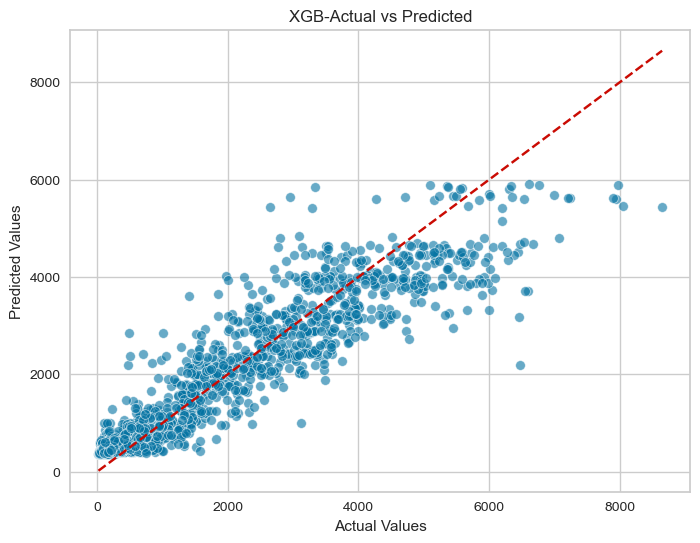

In [8]:
# 4. Actual vs Predicted Plot
def plot_actual_vs_predicted(y_true, y_pred):
    """Scatter plot of actual vs predicted values"""
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()], 
             [y_true.min(), y_true.max()], 'r--')
    plt.title('XGB-Actual vs Predicted')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.grid(True)
    plt.show()

y_pred_test = model.predict(X_test)
plot_actual_vs_predicted(y_test, y_pred_test)

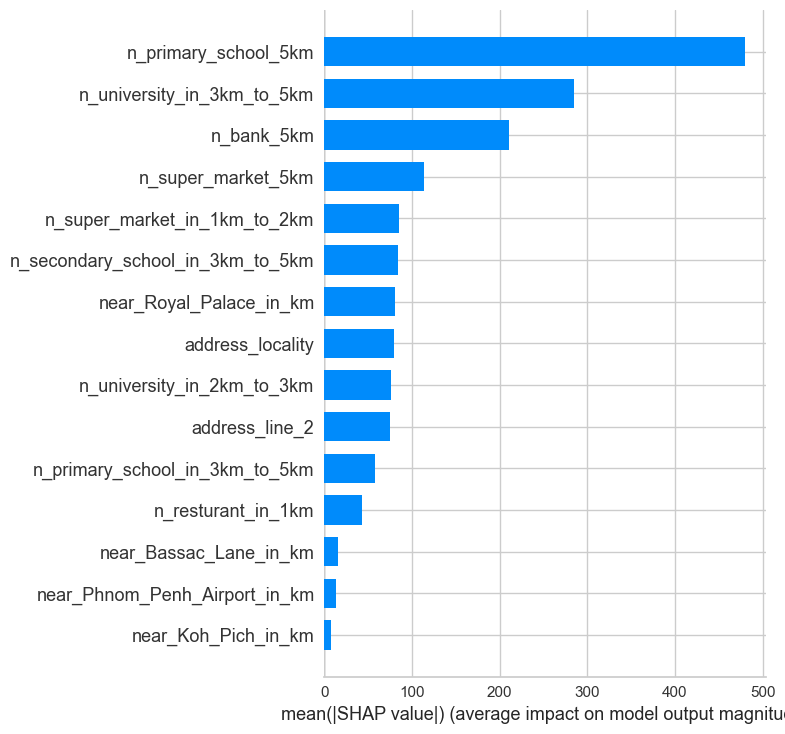

<Figure size 800x550 with 0 Axes>

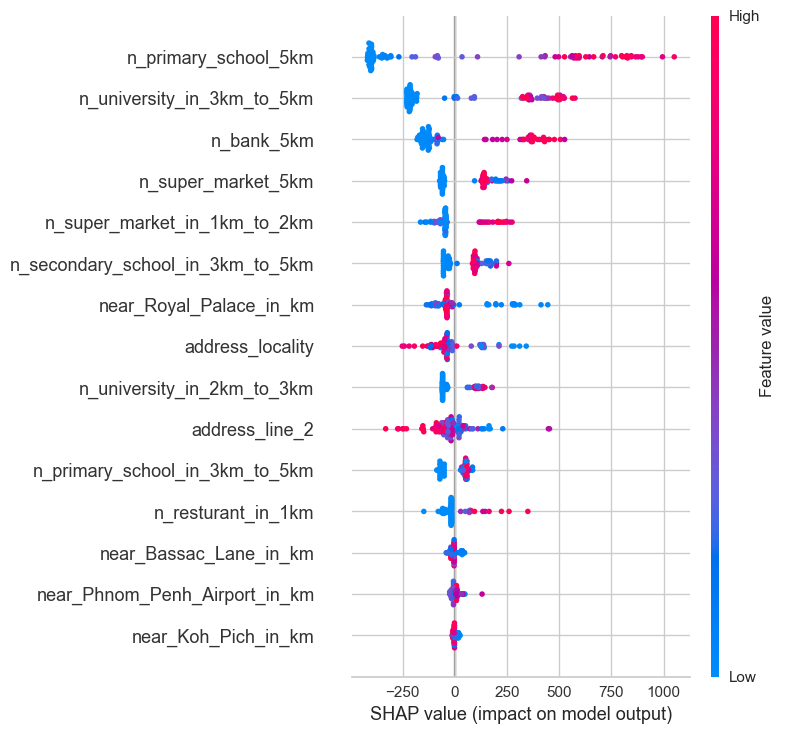

<Figure size 800x550 with 0 Axes>

In [9]:
def plot_shap_summary(model, X, sample_size=100):
    """Generate SHAP summary plot (using a sample for efficiency)"""
    X_sample = X.sample(sample_size, random_state=42)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    
    plt.figure()
    shap.summary_plot(shap_values, X_sample, plot_type="bar")
    plt.tight_layout()
    plt.show()
    
    plt.figure()
    shap.summary_plot(shap_values, X_sample)
    plt.tight_layout()
    plt.show()
    
plot_shap_summary(model, X_test)


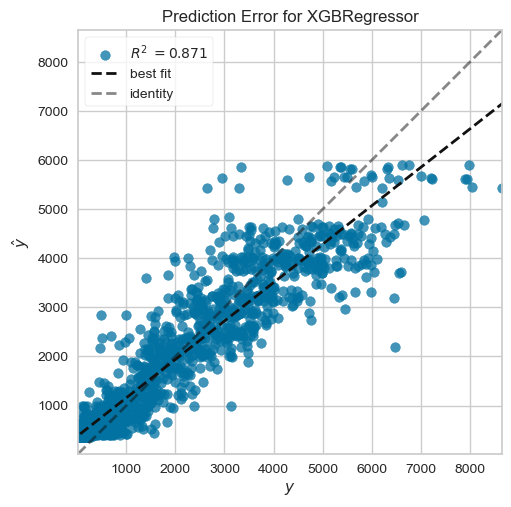

In [10]:
def plot_prediction_error(model, X_train, y_train, X_test, y_test):
    """Visualize prediction error with 45-degree line"""
    visualizer = prediction_error(
        model, X_train, y_train, X_test, y_test,
        bestfit=True, identity=True
    )
    visualizer.show()

plot_prediction_error(model, X_train, y_train, X_test, y_test)

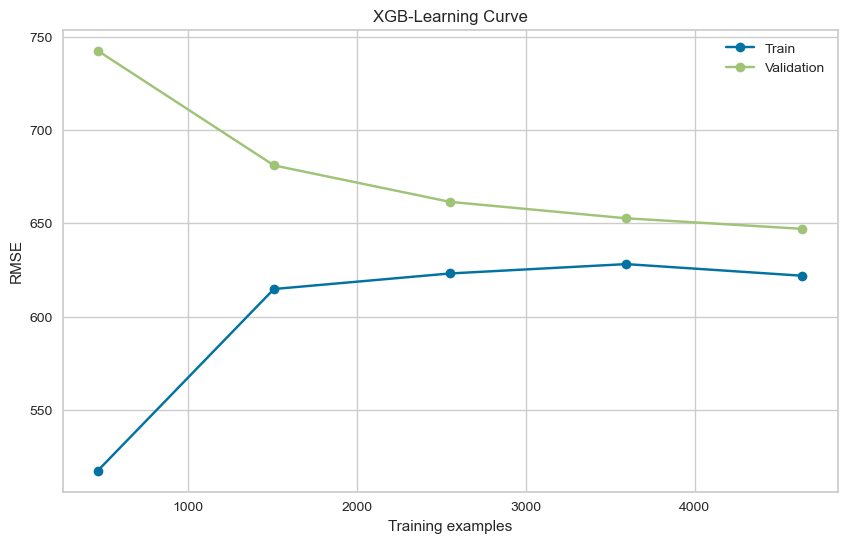

In [11]:
def plot_learning_curve(estimator, X, y):
    """Plot learning curve showing training and validation scores"""
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='neg_root_mean_squared_error'
    )
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, -train_scores.mean(1), 'o-', label='Train')
    plt.plot(train_sizes, -test_scores.mean(1), 'o-', label='Validation')
    plt.xlabel('Training examples')
    plt.ylabel('RMSE')
    plt.title('XGB-Learning Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning_curve(model, X_train, y_train)

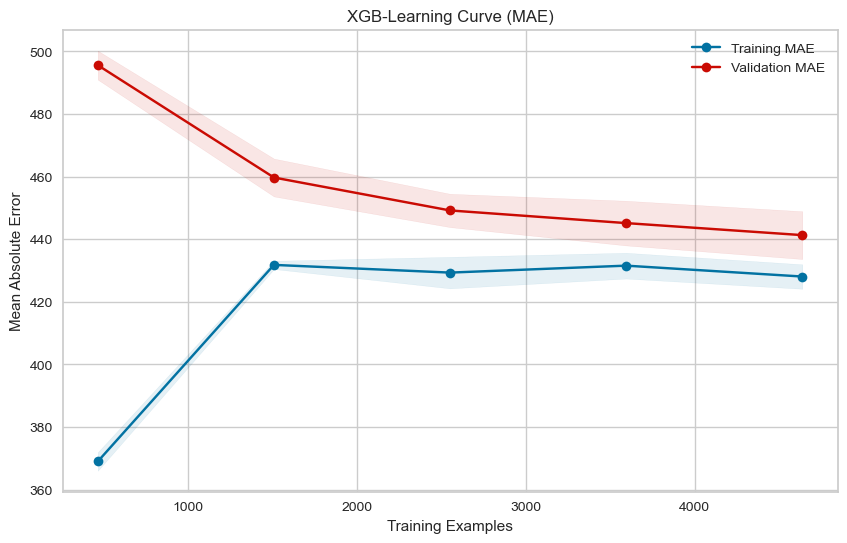

In [12]:
def plot_mae_learning_curve(estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)):
    """
    Generate MAE-based learning curve to diagnose bias/variance
    
    Parameters:
    estimator : Your trained model (tuned_rf in your case)
    X, y      : Features and target
    cv        : Cross-validation folds
    train_sizes : Proportion of dataset to use for curve points
    """
    # Calculate learning curve data using MAE
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        n_jobs=-1,
        train_sizes=train_sizes,
        scoring='neg_mean_absolute_error'  # Negative MAE (sklearn convention)
    )
    
    # Convert to positive MAE
    train_mae = -train_scores
    val_mae = -val_scores
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mae.mean(axis=1), 'o-', color='b', label='Training MAE')
    plt.plot(train_sizes, val_mae.mean(axis=1), 'o-', color='r', label='Validation MAE')
    
    # Formatting
    plt.title('XGB-Learning Curve (MAE)')
    plt.xlabel('Training Examples')
    plt.ylabel('Mean Absolute Error')
    plt.legend()
    plt.grid(True)
    
    # Add error bands
    plt.fill_between(train_sizes, 
                    train_mae.mean(axis=1) - train_mae.std(axis=1),
                    train_mae.mean(axis=1) + train_mae.std(axis=1),
                    alpha=0.1, color='b')
    
    plt.fill_between(train_sizes,
                    val_mae.mean(axis=1) - val_mae.std(axis=1),
                    val_mae.mean(axis=1) + val_mae.std(axis=1),
                    alpha=0.1, color='r')
    
    plt.show()

# Generate the plot
plot_mae_learning_curve(model, X_train, y_train)

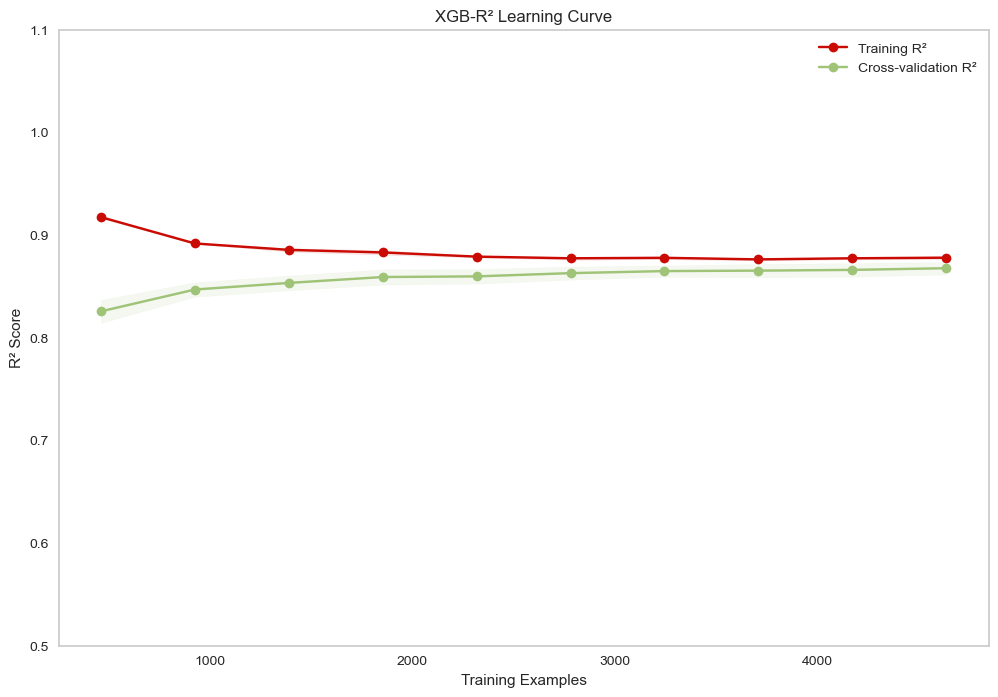

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.metrics import r2_score

def plot_r2_learning_curve(estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    """
    Generate R² learning curve with confidence intervals
    
    Parameters:
    estimator : Your trained model (tuned_rf)
    X, y      : Features and target
    cv        : Cross-validation folds
    train_sizes : Proportion increments to evaluate
    """
    # Calculate learning curve scores
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        n_jobs=-1,
        train_sizes=train_sizes,
        scoring='r2'
    )
    
    # Calculate mean and std
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    # Plotting
    plt.figure(figsize=(12, 8))
    plt.title("XGB-R² Learning Curve")
    plt.xlabel("Training Examples")
    plt.ylabel("R² Score")
    plt.ylim(0.5, 1.1)
    
    # Plot bands
    plt.fill_between(train_sizes, 
                    train_scores_mean - train_scores_std,
                    train_scores_mean + train_scores_std,
                    alpha=0.1, color="r")
    plt.fill_between(train_sizes, 
                    test_scores_mean - test_scores_std,
                    test_scores_mean + test_scores_std,
                    alpha=0.1, color="g")
    
    # Plot lines
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training R²")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation R²")
    
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Generate the plot
plot_r2_learning_curve(model, X_train, y_train)

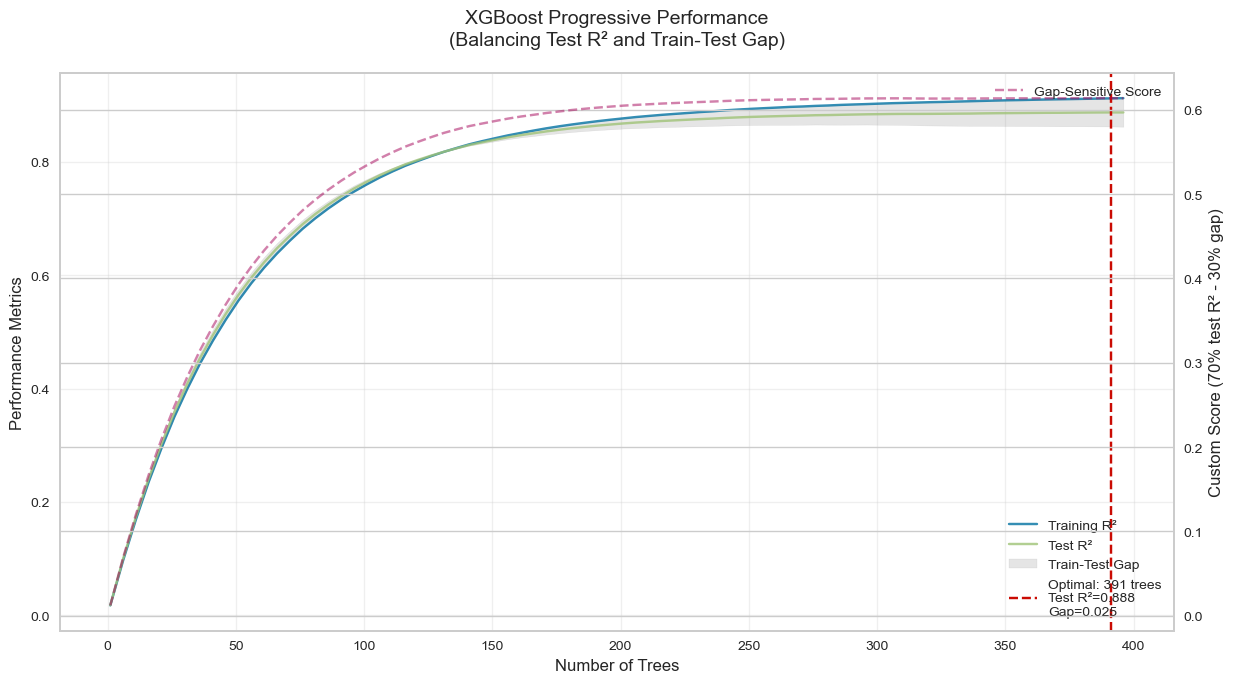

In [14]:
def plot_xgb_r2_progressive(trained_xgb, X_train, y_train, X_test, y_test, max_trees=400):
    """Track R² and gaps as trees are added (single plot version)"""
    train_r2 = []
    test_r2 = []
    gaps = []
    gap_sensitive_scores = []
    
    # Clone model with your preferred settings
    model = clone(trained_xgb)
    model.set_params(
        n_estimators=1,
        early_stopping_rounds=None,
        n_jobs=1  # Better for iterative training
    )
    
    # Evaluate every 5 trees up to max_trees
    tree_counts = range(1, max_trees+1, 5)
    
    for n_trees in tree_counts:
        model.n_estimators = n_trees
        model.fit(X_train, y_train, verbose=False)
        
        # Get predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        # Calculate metrics
        current_train_r2 = r2_score(y_train, y_train_pred)
        current_test_r2 = r2_score(y_test, y_test_pred)
        current_gap = abs(current_train_r2 - current_test_r2)
        
        train_r2.append(current_train_r2)
        test_r2.append(current_test_r2)
        gaps.append(current_gap)
        gap_sensitive_scores.append(0.7*current_test_r2 - 0.3*current_gap)
    
    # Create figure
    plt.figure(figsize=(12, 7))
    
    # Plot R² values
    plt.plot(tree_counts, train_r2, 'b-', label='Training R²', alpha=0.8)
    plt.plot(tree_counts, test_r2, 'g-', label='Test R²', alpha=0.8)
    
    # Plot gap (as shaded area)
    plt.fill_between(
        tree_counts, 
        np.array(test_r2) - np.array(gaps), 
        np.array(test_r2) + np.array(gaps),
        color='gray', 
        alpha=0.2, 
        label='Train-Test Gap'
    )
    
    # Mark optimal point based on your custom metric
    optimal_idx = np.argmax(gap_sensitive_scores)
    plt.axvline(
        x=tree_counts[optimal_idx],
        color='r',
        linestyle='--',
        label=f'Optimal: {tree_counts[optimal_idx]} trees\n'
              f'Test R²={test_r2[optimal_idx]:.3f}\n'
              f'Gap={gaps[optimal_idx]:.3f}'
    )
    
    # Formatting
    plt.xlabel('Number of Trees', fontsize=12)
    plt.ylabel('Performance Metrics', fontsize=12)
    plt.title('XGBoost Progressive Performance\n'
              '(Balancing Test R² and Train-Test Gap)', 
              fontsize=14, pad=20)
    
    plt.legend(loc='lower right', framealpha=1)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Add gap-sensitive score on secondary axis
    ax2 = plt.gca().twinx()
    ax2.plot(
        tree_counts, 
        gap_sensitive_scores, 
        'm--', 
        label='Gap-Sensitive Score',
        alpha=0.5
    )
    ax2.set_ylabel('Custom Score (70% test R² - 30% gap)', fontsize=12)
    ax2.legend(loc='upper right')
    
    plt.show()
    
    return {
        'tree_counts': tree_counts,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'gaps': gaps,
        'optimal_trees': tree_counts[optimal_idx]
    }

plot_results = plot_xgb_r2_progressive(model, X_train, y_train, X_test, y_test)

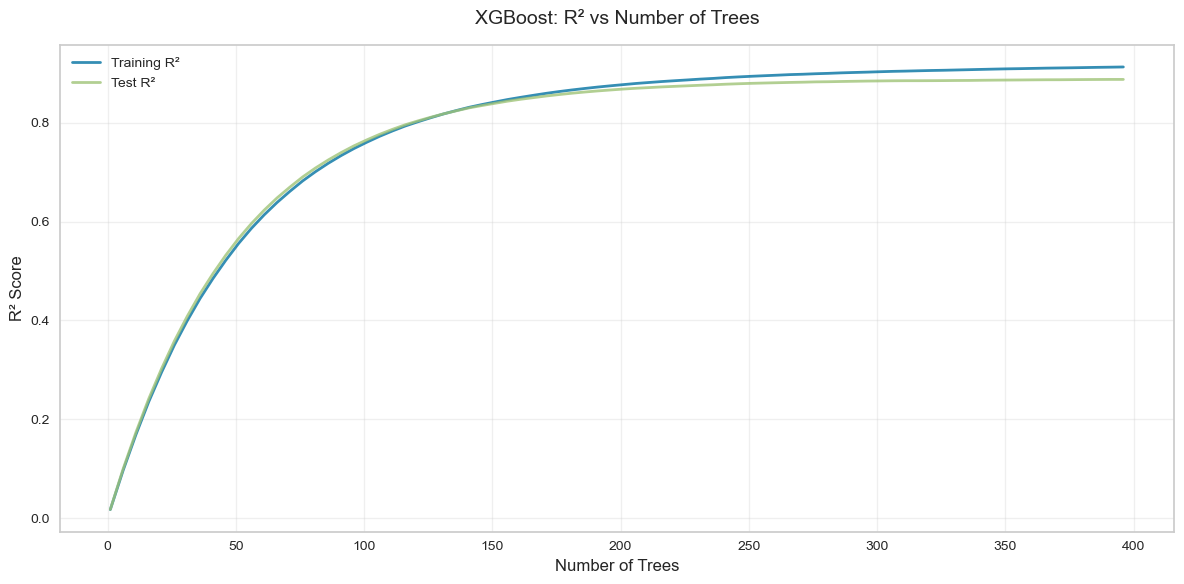

In [15]:
def plot_xgb_r2_progressive_simple(trained_xgb, X_train, y_train, X_test, y_test, max_trees=400):
    """Track only R² progression (training vs test) in one plot"""
    train_r2 = []
    test_r2 = []
    gaps = []
    
    # Clone model
    model = clone(trained_xgb)
    model.set_params(
        n_estimators=1,
        early_stopping_rounds=None,
        n_jobs=1
    )
    
    tree_counts = range(1, max_trees+1, 5)
    
    for n_trees in tree_counts:
        model.n_estimators = n_trees
        model.fit(X_train, y_train, verbose=False)
        
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        train_r2.append(r2_score(y_train, y_train_pred))
        test_r2.append(r2_score(y_test, y_test_pred))
        gaps.append(abs(train_r2[-1] - test_r2[-1]))
    
    # Calculate optimal point based on your 70/30 metric
    gap_sensitive_scores = [0.7*t - 0.3*g for t, g in zip(test_r2, gaps)]
    optimal_idx = np.argmax(gap_sensitive_scores)
    
    # Plotting
    plt.figure(figsize=(12, 6))
    
    # R² lines
    plt.plot(tree_counts, train_r2, 'b-', label='Training R²', linewidth=2, alpha=0.8)
    plt.plot(tree_counts, test_r2, 'g-', label='Test R²', linewidth=2, alpha=0.8)
    
    # Optimal point marker
    # plt.scatter(
    #     tree_counts[optimal_idx], 
    #     test_r2[optimal_idx], 
    #     color='red', 
    #     s=100,
    #     label=f'Optimal: {tree_counts[optimal_idx]} trees\n'
    #           f'Test R² = {test_r2[optimal_idx]:.3f}'
    # )
    
    # Formatting
    plt.xlabel('Number of Trees', fontsize=12)
    plt.ylabel('R² Score', fontsize=12)
    plt.title('XGBoost: R² vs Number of Trees', fontsize=14, pad=15)
    plt.legend(loc='best', framealpha=1)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'tree_counts': tree_counts,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'optimal_trees': tree_counts[optimal_idx]
    }

# Usage
plot_results = plot_xgb_r2_progressive_simple(model, X_train, y_train, X_test, y_test)